# Classifier Classifier

Solution author: cowile

For each of the ten classes we synthesise one 28x28 image (a *probe*) by gradient ascent on its pixels until every labeled model trained on that class outputs a high logit and every other labeled model outputs a low one. At test time each unlabeled model is run on all ten probes, and whichever probe gives it the highest logit names its class. This is called [activation maximisation](https://arxiv.org/abs/1312.6034).

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

In [2]:
SEED = 2026
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [4]:
class Model(nn.Module):
    def __init__(self, seed=42):
        super().__init__()
        layers = []
        in_ch = 1
        rng = random.Random(seed)
        num_blocks = rng.randint(2, 3)
        for _ in range(num_blocks):
            out_ch = rng.choice([8, 16, 32])
            k = rng.choice([3, 5])
            padding = k // 2
            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=padding))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            in_ch = out_ch
        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_ch, 1)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [5]:
BASE = '/kaggle/input/competitions/classifier-classifier-aicc-round-6'
data = torch.load(f'{BASE}/models.pt', map_location='cpu', weights_only=False)


def build(item):
    m = Model(seed=item['seed'])
    m.load_state_dict(item['state_dict'])
    return m.to(device).eval().requires_grad_(False)


train_models = [build(it) for it in data['train_models']]
train_labels = np.array([it['target_class'] for it in data['train_models']])
test_models = [build(it) for it in data['test_models']]

In [6]:
def query(models, x):
    return torch.stack([m(x).squeeze(1) for m in models])

## Ensembling gradients

A single model is easy to fool: gradient ascent on its logit finds an input that exploits its specific quirks, the pixel patterns its conv filters happen to be sensitive to, with no semantic meaning, so we get an adversarial example where the source model gives a high logit and every other model trained on the same class gives near zero. This goes away once we optimise against five classifiers for the same class at once, because the only direction in pixel space that satisfies all five independent networks is the actual class feature, and the artefacts of any individual model cancel out across the ensemble.

The loss is BCE against a one hot target of shape (50 models x 10 classes), with `pos_weight=9` set to balance the five positives against the forty five negatives per probe. We optimise all ten probes concurrently in one (10, 1, 28, 28) tensor, and because Adam keeps first and second moments per element, each probe sees only its own gradient, which makes the whole run equivalent to ten independent ones.

We start with gradient ascent directly on the raw pixel values, lightly clamped.

In [7]:
target_oh = F.one_hot(torch.from_numpy(train_labels).to(device), 10).float()  # (M, 10)
pos_weight = torch.tensor(9.0, device=device)


def probe_loss(imgs):
    logits = query(train_models, imgs)  # (M, 10)
    return F.binary_cross_entropy_with_logits(
        logits, target_oh, pos_weight=pos_weight, reduction='sum',
    ) / len(train_models)

In [8]:
torch.manual_seed(SEED)
img = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
opt = torch.optim.Adam([img], lr=0.03)

for _ in range(400):
    opt.zero_grad()
    probe_loss(img).backward()
    opt.step()
    with torch.no_grad():
        img.clamp_(-3, 3)

probes_raw = img.detach()

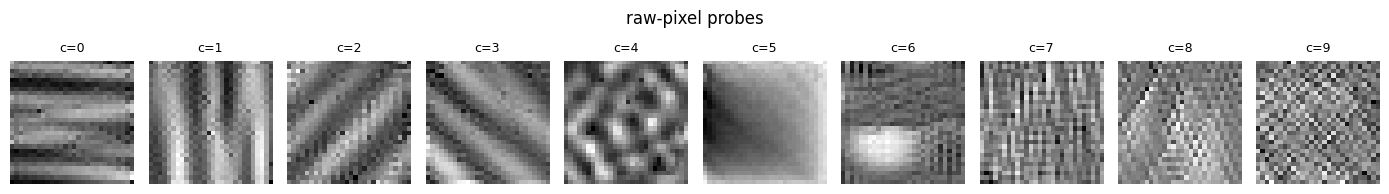

In [9]:
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for c, ax in enumerate(axes):
    ax.imshow(probes_raw[c, 0].cpu(), cmap='gray')
    ax.set_title(f'c={c}', fontsize=9)
    ax.axis('off')
plt.suptitle('raw-pixel probes')
plt.tight_layout()
plt.show()

The probes have collapsed to pixel values pinned at the clamp boundaries, far outside the [0, 1] range the models actually saw during training. The labeled models still fire by construction, but the test models have never seen inputs like this and barely respond, so the probes are *off the manifold*.

## Sigmoid and low frequency init

Two changes bring the probes back in domain. The first is sigmoid reparameterisation: instead of optimising the image directly, we optimise an unconstrained latent `z` and treat `sigmoid(z)` as the probe, so the probe stays in [0, 1] by construction and the optimiser can push `z` arbitrarily far in either direction without ever leaving the input domain the models were trained on. The second is low frequency initialisation: we start `z` from a 7x7 noise tensor bilinearly upsampled to 28x28, so early gradients flow over a smooth landscape and gradient descent settles into smooth solutions rather than the high frequency adversarial ones it would otherwise find.

Either fix alone is enough, and [total variation regularisation](https://en.wikipedia.org/wiki/Total_variation_denoising) on the probe is an alternative fix.

In [10]:
torch.manual_seed(SEED)
z = F.interpolate(
    torch.randn(10, 1, 7, 7, device=device),
    size=28, mode='bilinear', align_corners=False,
).requires_grad_()
opt = torch.optim.Adam([z], lr=0.05)

for _ in range(400):
    opt.zero_grad()
    probe_loss(torch.sigmoid(z)).backward()
    opt.step()

probes_sig = torch.sigmoid(z).detach()

In [11]:
with torch.no_grad():
    test_scores = query(test_models, probes_sig).cpu().numpy()
    train_scores = query(train_models, probes_sig).cpu().numpy()

pred_sig = test_scores.argmax(1)
print(f'train f1-macro: {f1_score(train_labels, train_scores.argmax(1), average="macro"):.3f}')

train f1-macro: 1.000


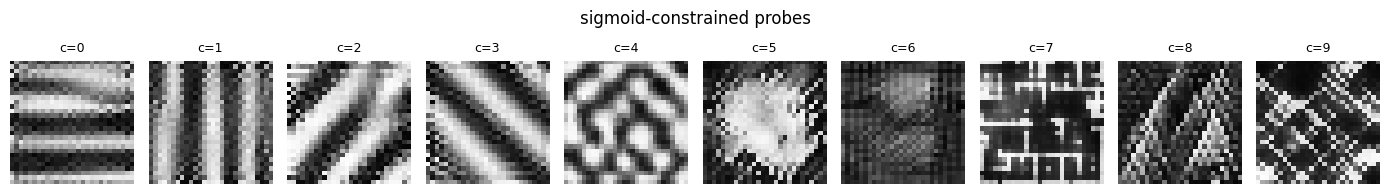

In [12]:
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for c, ax in enumerate(axes):
    ax.imshow(probes_sig[c, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'c={c}', fontsize=9)
    ax.axis('off')
plt.suptitle('sigmoid-constrained probes')
plt.tight_layout()
plt.show()

Probes converge to a *texture* for each class rather than a *picture* of that class. Every classifier ends in global average pooling, which averages out spatial structure before the final linear layer, so what matters is the local pattern, not where it sits in the image.

In [13]:
sub = pd.DataFrame({'id': range(len(pred_sig)), 'class': pred_sig})
sub.to_csv('submission.csv', index=False)
sub.head()

,id,class
0,0,8
1,1,0
2,2,2
3,3,2
4,4,4
